In [70]:
import sys
import os
sys.path.append(os.path.dirname(os.getcwd()))
from shared.collect_data import DataCollector
from shared.clean_data import DataCleaning
import ta
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "02_model_training"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Data Collection

In [3]:
data_collector = DataCollector(
    symbol = "BTC/USDT", 
    timeframe = "15m", 
    days = 365,
    limit = 1000
)
df = data_collector.collect_data()

In [4]:
df.head()

,timestamp,open,high,low,close,volume
0,2024-09-03 01:15:00,59270.01,59325.55,59203.00,59262.00,102.43589
1,2024-09-03 01:30:00,59262.00,59289.00,59195.50,59212.00,64.80392
2,2024-09-03 01:45:00,59212.00,59403.99,59195.41,59388.01,159.65941
3,2024-09-03 02:00:00,59388.01,59807.42,59347.00,59764.00,818.21451
4,2024-09-03 02:15:00,59763.99,59809.65,59565.00,59581.10,333.29467


# Technical Indicators

### Momentum

In [6]:
##Awesome Oscillator (AO)
df["AO"] = ta.momentum.AwesomeOscillatorIndicator(
    high=df["high"],
    low=df["low"],
    window1=5,
    window2=34
).awesome_oscillator()


In [7]:
##KAMA
df["KAMA"] = ta.momentum.KAMAIndicator(close=df['close']).kama()

In [8]:
## PPO
ppo = ta.momentum.PercentagePriceOscillator(
    close=df['close'],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["PPO"] = ppo.ppo()

df["PPO_HIST"] = ppo.ppo_hist()

df["PPO_SIGNAL"] = ppo.ppo_signal()

In [9]:
## PVO
pvo = ta.momentum.PercentageVolumeOscillator(
    volume =df['volume'],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["PVO"] = pvo.pvo()

df["PVO_HIST"] = pvo.pvo_hist()

df["PVO_SIGNAL"] = pvo.pvo_signal()

In [10]:
## ROC
df["ROC"] = ta.momentum.ROCIndicator(
    close=df['close'],
    window=12
).roc()

In [11]:
## RSI
df["RSI"] = ta.momentum.RSIIndicator(close=df['close'], window=14).rsi()

In [12]:
## STOCHASTIC RSI
df["STOCH_RSI"] = ta.momentum.StochRSIIndicator(
    close=df['close'],
    window=14,
    smooth1=3,
    smooth2=3
).stochrsi()

In [13]:
## STOCHASTIC OSCILLATOR
stoch = ta.momentum.StochasticOscillator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    window=14,
    smooth_window=3
)

df["STOCH_OSC"] = stoch.stoch()

df["STOCH_OSC_SIGNAL"] = stoch.stoch_signal()

In [14]:
## TSI
df["TSI"] = ta.momentum.TSIIndicator(
    close=df['close'],
    window_slow=25,
    window_fast=13
).tsi()

### Volume

In [15]:
## ADI
adi = ta.volume.AccDistIndexIndicator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    volume=df['volume']
)

df["ADI"] = adi.acc_dist_index()

In [16]:
## CMF
cmf = ta.volume.ChaikinMoneyFlowIndicator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    volume=df['volume'],
    window=20
)

df["CMF"] = cmf.chaikin_money_flow()

In [17]:
##EoM EMV
emi = ta.volume.EaseOfMovementIndicator(
    high=df["high"], low=df["low"], volume=df["volume"], window=14
)

df["EoM"] = emi.ease_of_movement()
df["EMV"] = emi.sma_ease_of_movement()

In [18]:
##FI
fi = ta.volume.ForceIndexIndicator(
    close=df["close"], volume=df["volume"], window=13
)

df["FI"] = fi.force_index()

In [19]:
##MFI
mfi = ta.volume.MFIIndicator(
    high=df["high"], low=df["low"], close=df["close"], volume=df["volume"], window=14
)

df["MFI"] = mfi.money_flow_index()

In [20]:
##NVI
nvi = ta.volume.NegativeVolumeIndexIndicator(
    close=df["close"], volume=df["volume"]
)

df["NVI"] = nvi.negative_volume_index()

In [21]:
##OBV
obv = ta.volume.OnBalanceVolumeIndicator(
    close=df["close"], volume=df["volume"]
)

df["OBV"] = obv.on_balance_volume()

In [22]:
##VPT
vpt = ta.volume.VolumePriceTrendIndicator(
    close=df["close"], volume=df["volume"]
)

df["VPT"] = vpt.volume_price_trend()

In [23]:
## VWAP
vwap = ta.volume.VolumeWeightedAveragePrice(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    volume=df["volume"],
    window=14
)

df["VWAP"] = vwap.volume_weighted_average_price()

### Volatility

In [24]:
## ATR
atr = ta.volatility.AverageTrueRange(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14,
)

df["ATR"] = atr.average_true_range()

In [25]:
## BBANDS
bbands = ta.volatility.BollingerBands(
    close=df["close"],
    window=20,
    window_dev=2
)

df["BBANDS_HIGH"] = bbands.bollinger_hband()
df["BBANDS_HIGH_INDI"] = bbands.bollinger_hband_indicator()
df["BBANDS_LOWER"] = bbands.bollinger_lband()
df["BBANDS_LOWER_INDI"] = bbands.bollinger_lband_indicator()
df["BBANDS_MIDDLE"] = bbands.bollinger_mavg()
df["BBANDS_CHANNEL"] = bbands.bollinger_pband()
df["BBANDS_WIDTH"] = bbands.bollinger_wband()

In [26]:
## DONCHIAN CHANNEL
donchian = ta.volatility.DonchianChannel(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20
)

df["DONCHIAN_HIGH"] = donchian.donchian_channel_hband()
df["DONCHIAN_LOW"] = donchian.donchian_channel_lband()
df["DONCHIAN_MIDDLE"] = donchian.donchian_channel_mband()
df["DONCHIAN_PERCENTAGE"] = donchian.donchian_channel_pband()
df["DONCHIAN_WIDTH"] = donchian.donchian_channel_wband()

In [27]:
## KELTNER CHANNEL
keltner = ta.volatility.KeltnerChannel(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20,
    window_atr=10,
)

df["KELTNER_HIGH"] = keltner.keltner_channel_hband()
df["KELTNER_HIGH_INDI"] = keltner.keltner_channel_hband_indicator()
df["KELTNER_LOW"] = keltner.keltner_channel_lband()
df["KELTNER_LOW_INDI"] = keltner.keltner_channel_lband_indicator()
df["KELTNER_MIDDLE"] = keltner.keltner_channel_mband()
df["KELTNER_PERCENTAGE"] = keltner.keltner_channel_pband()
df["KELTNER_WIDTH"] = keltner.keltner_channel_wband()

In [28]:
## Ulcer Index
ui = ta.volatility.UlcerIndex(
    close=df["close"],
    window=14
)

df["ULCER_INDEX"] = ui.ulcer_index()

### Trend

In [29]:
## ADX
adx = ta.trend.ADXIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14,
)

df["ADX"] = adx.adx()
df["ADX_POS"] = adx.adx_pos()
df["ADX_NEG"] = adx.adx_neg()

In [30]:
## AROON
aroon = ta.trend.AroonIndicator(
    high=df["high"],
    low=df["low"],
    window=25
)

df["AROON_UP"] = aroon.aroon_up()
df["AROON_DOWN"] = aroon.aroon_down()
df["AROON_INDI"] = aroon.aroon_indicator()

In [31]:
## CCI
cci = ta.trend.CCIIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20
)

df["CCI"] = cci.cci()

In [32]:
## DPO
dpo = ta.trend.DPOIndicator(
    close=df["close"],
    window=20
)

df["DPO"] = dpo.dpo()

In [33]:
## EMA
ema = ta.trend.EMAIndicator(
    close=df["close"],
    window=14
)

df["EMA"] = ema.ema_indicator()

In [34]:
## KST
kst = ta.trend.KSTIndicator(
    close=df["close"],
    roc1=10,
    roc2=15,
    roc3=20,
    roc4=30,
    window1=10,
    window2=10,
    window3=10,
    window4=15,
    nsig =9
)

df["KST"] = kst.kst()
df["KST_SIGNAL"] = kst.kst_sig()
df["KST_DIFF"] = kst.kst_diff()

In [35]:
## MACD
macd = ta.trend.MACD(
    close=df["close"],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["MACD"] = macd.macd()
df["MACD_SIGNAL"] = macd.macd_signal()
df["MACD_DIFF"] = macd.macd_diff()

In [36]:
## MI
mi = ta.trend.MassIndex(
    high=df["high"],
    low=df["low"],
    window_slow=25,
    window_fast=9
)

df["MASS_INDEX"] = mi.mass_index()

In [37]:
## SMA
sma = ta.trend.SMAIndicator(
    close=df["close"],
    window=14
)

df["SMA"] = sma.sma_indicator()

In [38]:
## VI
vi = ta.trend.VortexIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14
)

df["VI_POS"] = vi.vortex_indicator_pos()
df["VI_NEG"] = vi.vortex_indicator_neg()
df["VI_DIFF"] = vi.vortex_indicator_diff()

In [39]:
## WMA
wma = ta.trend.WMAIndicator(
    close=df["close"],
    window=14
)

df["WMA"] = wma.wma()

In [40]:
df.head()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA,VI_POS,VI_NEG,VI_DIFF,WMA
0,2024-09-03 01:15:00,59270.01,59325.55,59203.00,59262.00,102.43589,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-09-03 01:30:00,59262.00,59289.00,59195.50,59212.00,64.80392,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-09-03 01:45:00,59212.00,59403.99,59195.41,59388.01,159.65941,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-09-03 02:00:00,59388.01,59807.42,59347.00,59764.00,818.21451,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-09-03 02:15:00,59763.99,59809.65,59565.00,59581.10,333.29467,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Constants

In [41]:
OCHLV = ["open", "close", "high", "low", "volume"]
MOMENTUM = ["AO", "KAMA", "PPO", "PPO_HIST", "PPO_SIGNAL", "PVO", "PVO_HIST", "PVO_SIGNAL", "ROC", "RSI", "STOCH_RSI", "STOCH_OSC", "STOCH_OSC_SIGNAL", "TSI"]
VOLUME = ["ADI", "CMF", "EoM", "EMV", "FI", "MFI", "NVI", "OBV", "VPT", "VWAP"]
VOLATILITY = ["ATR", "BBANDS_HIGH", "BBANDS_HIGH_INDI", "BBANDS_LOWER", "BBANDS_LOWER_INDI", "BBANDS_MIDDLE", "BBANDS_CHANNEL", "BBANDS_WIDTH", "DONCHIAN_HIGH", "DONCHIAN_LOW", "DONCHIAN_MIDDLE", "DONCHIAN_PERCENTAGE", "DONCHIAN_WIDTH", "KELTNER_HIGH", "KELTNER_HIGH_INDI", "KELTNER_LOW", "KELTNER_LOW_INDI", "KELTNER_MIDDLE", "KELTNER_PERCENTAGE", "KELTNER_WIDTH", "ULCER_INDEX"]
TREND = ["ADX", "ADX_POS", "ADX_NEG", "AROON_UP", "AROON_DOWN", "AROON_INDI", "CCI", "DPO", "EMA", "KST", "KST_SIGNAL", "KST_DIFF", "MACD", "MACD_SIGNAL", "MACD_DIFF", "MASS_INDEX", "SMA", "VI_POS", "VI_NEG", "VI_DIFF", "WMA"]

# Explore Data

### Correlation

In [42]:
# OCHLV with MOMENTUM
df[OCHLV + MOMENTUM].corr()

,open,close,high,low,volume,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,PVO,PVO_HIST,PVO_SIGNAL,ROC,RSI,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL,TSI
open,1.000000,0.999912,0.999948,0.999941,-0.106198,0.015688,0.999810,0.009090,-0.001891,0.010005,0.002741,0.000202,0.003230,0.001729,0.002702,-0.009040,0.000887,0.004681,0.007827
close,0.999912,1.000000,0.999952,0.999948,-0.106115,0.016040,0.999753,0.009944,0.000537,0.010137,0.002712,0.000189,0.003203,0.005446,0.007219,-0.003272,0.006184,0.006494,0.008726
high,0.999948,0.999952,1.000000,0.999902,-0.100768,0.015503,0.999783,0.009124,-0.000828,0.009701,0.005578,0.002346,0.005370,0.003361,0.004771,-0.006032,0.003277,0.005364,0.007995
low,0.999941,0.999948,0.999902,1.000000,-0.112010,0.016608,0.999749,0.010226,-0.000071,0.010631,-0.000268,-0.002125,0.000990,0.004392,0.005768,-0.005835,0.003914,0.006079,0.008923
volume,-0.106198,-0.106115,-0.100768,-0.112010,1.000000,-0.007380,-0.105102,0.003598,-0.025424,0.011917,0.505620,0.421950,0.358120,-0.010683,-0.009429,-0.011825,-0.018207,-0.017916,0.002434
AO,0.015688,0.016040,0.015503,0.016608,-0.007380,1.000000,0.003714,0.959257,0.449764,0.874918,-0.054362,-0.006280,-0.061098,0.730262,0.745350,0.043098,0.426087,0.531427,0.867054
KAMA,0.999810,0.999753,0.999783,0.999749,-0.105102,0.003714,1.000000,-0.002381,-0.014073,0.001711,0.004170,0.000797,0.004588,-0.011073,-0.010038,-0.015823,-0.010030,-0.008571,-0.003150
PPO,0.009090,0.009944,0.009124,0.010226,0.003598,0.959257,-0.002381,1.000000,0.338440,0.953746,-0.045006,0.000852,-0.054056,0.700780,0.758756,0.012039,0.402593,0.487053,0.892465
PPO_HIST,-0.001891,0.000537,-0.000828,-0.000071,-0.025424,0.449764,-0.014073,0.338440,1.000000,0.039911,-0.050578,-0.045028,-0.034193,0.826150,0.566321,0.593172,0.643887,0.692406,0.311076
PPO_SIGNAL,0.010005,0.010137,0.009701,0.010631,0.011917,0.874918,0.001711,0.953746,0.039911,1.000000,-0.031610,0.015290,-0.046477,0.480198,0.624780,-0.176756,0.221771,0.295951,0.848302


In [43]:
# OCHLV with VOLUME
df[OCHLV + VOLUME].corr()

,open,close,high,low,volume,ADI,CMF,EoM,EMV,FI,MFI,NVI,OBV,VPT,VWAP
open,1.000000,0.999912,0.999948,0.999941,-0.106198,0.749447,0.033550,-0.004844,0.009448,0.011834,0.008953,0.762109,0.605979,0.824210,0.999787
close,0.999912,1.000000,0.999952,0.999948,-0.106115,0.749389,0.035794,0.003430,0.011438,0.015781,0.010805,0.762124,0.605990,0.824246,0.999725
high,0.999948,0.999952,1.000000,0.999902,-0.100768,0.750454,0.034298,0.000190,0.010272,0.013846,0.009812,0.761416,0.607155,0.825031,0.999756
low,0.999941,0.999948,0.999902,1.000000,-0.112010,0.748424,0.034523,0.000846,0.011564,0.014608,0.010636,0.762985,0.604666,0.823294,0.999731
volume,-0.106198,-0.106115,-0.100768,-0.112010,1.000000,-0.017109,0.027316,-0.029859,-0.054185,0.059292,-0.012024,-0.200017,0.076967,0.023298,-0.105824
ADI,0.749447,0.749389,0.750454,0.748424,-0.017109,1.000000,-0.026758,0.000149,0.000459,-0.019343,-0.012060,0.464873,0.772023,0.800555,0.749200
CMF,0.033550,0.035794,0.034298,0.034523,0.027316,-0.026758,1.000000,0.134899,0.415750,0.271879,0.549449,-0.032287,0.039512,0.044569,0.025496
EoM,-0.004844,0.003430,0.000190,0.000846,-0.029859,0.000149,0.134899,1.000000,0.242952,0.209452,0.132889,0.002269,-0.001288,-0.000978,-0.007092
EMV,0.009448,0.011438,0.010272,0.011564,-0.054185,0.000459,0.415750,0.242952,1.000000,0.411288,0.677484,0.004622,-0.002016,0.001097,-0.005457
FI,0.011834,0.015781,0.013846,0.014608,0.059292,-0.019343,0.271879,0.209452,0.411288,1.000000,0.321465,-0.007770,0.007923,0.028415,0.002963


In [44]:
# OCHLV with VOLATILITY
df[OCHLV + VOLATILITY].corr()

,open,close,high,low,volume,ATR,BBANDS_HIGH,BBANDS_HIGH_INDI,BBANDS_LOWER,BBANDS_LOWER_INDI,...,DONCHIAN_PERCENTAGE,DONCHIAN_WIDTH,KELTNER_HIGH,KELTNER_HIGH_INDI,KELTNER_LOW,KELTNER_LOW_INDI,KELTNER_MIDDLE,KELTNER_PERCENTAGE,KELTNER_WIDTH,ULCER_INDEX
open,1.000000,0.999912,0.999948,0.999941,-0.106198,0.133678,0.999148,-0.010576,0.999073,-0.004976,...,0.000723,-0.137098,0.999482,0.003301,0.999499,0.008336,0.999536,0.004921,-0.170617,-0.100096
close,0.999912,1.000000,0.999952,0.999948,-0.106115,0.133759,0.999076,-0.006637,0.998995,-0.009035,...,0.005429,-0.136931,0.999405,0.006346,0.999421,0.005093,0.999458,0.009684,-0.170515,-0.100456
high,0.999948,0.999952,1.000000,0.999902,-0.100768,0.138272,0.999223,-0.007177,0.998931,-0.005801,...,0.002780,-0.132915,0.999489,0.005306,0.999424,0.007557,0.999502,0.007214,-0.166415,-0.097547
low,0.999941,0.999948,0.999902,1.000000,-0.112010,0.128951,0.998964,-0.009641,0.999107,-0.008603,...,0.003565,-0.141272,0.999363,0.004719,0.999465,0.005464,0.999459,0.007966,-0.174858,-0.103224
volume,-0.106198,-0.106115,-0.100768,-0.112010,1.000000,0.519960,-0.091094,0.220916,-0.120377,0.206616,...,-0.021672,0.572632,-0.100791,0.101815,-0.110210,0.146390,-0.105787,-0.001845,0.508074,0.319746
ATR,0.133678,0.133759,0.138272,0.128951,0.519960,1.000000,0.156398,0.006696,0.110220,0.012438,...,-0.000214,0.832096,0.144104,0.003040,0.125467,0.047493,0.133405,-0.018158,0.922726,0.637205
BBANDS_HIGH,0.999148,0.999076,0.999223,0.998964,-0.091094,0.156398,1.000000,-0.017904,0.998218,0.002232,...,-0.018306,-0.110028,0.999735,-0.009632,0.999280,0.029272,0.999554,-0.017612,-0.146819,-0.066657
BBANDS_HIGH_INDI,-0.010576,-0.006637,-0.007177,-0.009641,0.220916,0.006696,-0.017904,1.000000,-0.018285,-0.062573,...,0.341740,0.032421,-0.018152,0.408064,-0.017876,-0.140774,-0.018303,0.424289,-0.008838,-0.118843
BBANDS_LOWER,0.999073,0.998995,0.998931,0.999107,-0.120377,0.110220,0.998218,-0.018285,1.000000,0.002211,...,-0.019385,-0.165002,0.999280,-0.018319,0.999736,0.021161,0.999554,-0.019396,-0.193005,-0.103181
BBANDS_LOWER_INDI,-0.004976,-0.009035,-0.005801,-0.008603,0.206616,0.012438,0.002232,-0.062573,0.002211,1.000000,...,-0.380672,0.019381,0.002587,-0.152520,0.002800,0.443363,0.002426,-0.432917,-0.011740,0.059477


In [45]:
# OCHLV with TREND
df[OCHLV + TREND].corr()

,open,close,high,low,volume,ADX,ADX_POS,ADX_NEG,AROON_UP,AROON_DOWN,...,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA,VI_POS,VI_NEG,VI_DIFF,WMA
open,1.000000,0.999912,0.999948,0.999941,-0.106198,-0.027976,0.018044,0.026277,0.005861,0.008688,...,-0.024039,0.018719,0.020251,-0.001657,-0.003637,0.999718,0.006149,-0.005834,0.006086,0.999856
close,0.999912,1.000000,0.999952,0.999948,-0.106115,-0.027985,0.020639,0.023585,0.006560,0.008013,...,-0.023290,0.019581,0.020380,0.000803,-0.003650,0.999646,0.007831,-0.007546,0.007809,0.999794
high,0.999948,0.999952,1.000000,0.999902,-0.100768,-0.026381,0.019846,0.025386,0.006968,0.009146,...,-0.023886,0.018732,0.019928,-0.000604,-0.001404,0.999683,0.006429,-0.007290,0.006960,0.999823
low,0.999941,0.999948,0.999902,1.000000,-0.112010,-0.029604,0.019962,0.023202,0.005841,0.007070,...,-0.023260,0.019882,0.020895,0.000193,-0.005969,0.999649,0.008436,-0.006884,0.007787,0.999798
volume,-0.106198,-0.106115,-0.100768,-0.112010,1.000000,0.246635,0.064081,0.105453,0.119298,0.114861,...,-0.016505,-0.003359,0.005573,-0.028598,0.293618,-0.105702,-0.078071,-0.059613,-0.010145,-0.105889
ADX,-0.027976,-0.027985,-0.026381,-0.029604,0.246635,1.000000,0.022626,0.038186,-0.004980,0.031721,...,-0.023171,-0.031359,-0.030874,-0.007863,0.368618,-0.029373,-0.007746,-0.008995,0.000540,-0.029548
ADX_POS,0.018044,0.020639,0.019846,0.019962,0.064081,0.022626,1.000000,-0.735949,0.589706,-0.526128,...,0.361508,0.718523,0.614351,0.464774,0.000522,0.000852,0.733504,-0.774483,0.765386,0.006192
ADX_NEG,0.026277,0.023585,0.025386,0.023202,0.105453,0.038186,-0.735949,1.000000,-0.518462,0.585894,...,-0.374796,-0.693113,-0.579434,-0.489649,0.113552,0.039473,-0.764079,0.737503,-0.762515,0.034122
AROON_UP,0.005861,0.006560,0.006968,0.005841,0.119298,-0.004980,0.589706,-0.518462,1.000000,-0.458962,...,0.271065,0.554375,0.516576,0.225678,0.053961,-0.002186,0.501333,-0.561765,0.539401,0.001114
AROON_DOWN,0.008688,0.008013,0.009146,0.007070,0.114861,0.031721,-0.526128,0.585894,-0.458962,1.000000,...,-0.278624,-0.570335,-0.529645,-0.237790,0.217844,0.017107,-0.556404,0.510420,-0.541893,0.013659


In [46]:
dataset = df.copy()

# Data Cleaning

In [47]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 72 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   timestamp            35040 non-null  datetime64[ns]
 1   open                 35040 non-null  float64       
 2   high                 35040 non-null  float64       
 3   low                  35040 non-null  float64       
 4   close                35040 non-null  float64       
 5   volume               35040 non-null  float64       
 6   AO                   35007 non-null  float64       
 7   KAMA                 35031 non-null  float64       
 8   PPO                  35015 non-null  float64       
 9   PPO_HIST             35007 non-null  float64       
 10  PPO_SIGNAL           35007 non-null  float64       
 11  PVO                  35015 non-null  float64       
 12  PVO_HIST             35007 non-null  float64       
 13  PVO_SIGNAL           35007 non-

In [48]:
dataset = DataCleaning(dataset).clean_data()

In [49]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35000 entries, 40 to 35039
Data columns (total 72 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   timestamp            35000 non-null  datetime64[ns]
 1   open                 35000 non-null  float64       
 2   high                 35000 non-null  float64       
 3   low                  35000 non-null  float64       
 4   close                35000 non-null  float64       
 5   volume               35000 non-null  float64       
 6   AO                   35000 non-null  float64       
 7   KAMA                 35000 non-null  float64       
 8   PPO                  35000 non-null  float64       
 9   PPO_HIST             35000 non-null  float64       
 10  PPO_SIGNAL           35000 non-null  float64       
 11  PVO                  35000 non-null  float64       
 12  PVO_HIST             35000 non-null  float64       
 13  PVO_SIGNAL           35000 non-null

# Feature Engineering

### Timestamp Features

In [50]:
dataset["hour"] = dataset['timestamp'].dt.hour
dataset['dayofweek'] = dataset['timestamp'].dt.dayofweek
dataset['quarter'] = dataset['timestamp'].dt.quarter
dataset['month'] = dataset['timestamp'].dt.month
dataset['year'] = dataset['timestamp'].dt.year
dataset['dayofyear'] = dataset['timestamp'].dt.dayofyear
dataset['dayofmonth'] = dataset['timestamp'].dt.day

### Lag Features (Targets)

In [51]:
def create_targets(df, target_column='close', n_steps=16):
    
    for step in range(1, n_steps + 1):
        df[f'close_step_{step}'] = df[target_column].shift(-step)
    
    return df


In [52]:
targets = create_targets(dataset, target_column='close', n_steps=16)

In [55]:
targets.tail(20)

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,close_step_7,close_step_8,close_step_9,close_step_10,close_step_11,close_step_12,close_step_13,close_step_14,close_step_15,close_step_16
35020,2025-09-02 20:15:00,111196.00,111350.00,111154.42,111252.00,163.09744,258.527706,110758.435984,0.108672,0.027413,...,111119.99,111048.00,111185.25,111259.99,111238.00,111078.81,111109.99,111240.01,111530.12,111647.99
35021,2025-09-02 20:30:00,111251.99,111389.99,111096.17,111289.21,163.15431,346.297941,110868.842278,0.133959,0.042160,...,111048.00,111185.25,111259.99,111238.00,111078.81,111109.99,111240.01,111530.12,111647.99,111417.72
35022,2025-09-02 20:45:00,111289.21,111419.18,111218.48,111418.49,90.11377,435.662059,111026.283430,0.161517,0.055775,...,111185.25,111259.99,111238.00,111078.81,111109.99,111240.01,111530.12,111647.99,111417.72,111339.98
35023,2025-09-02 21:00:00,111418.49,111517.84,111371.48,111517.83,112.67626,516.171088,111169.873106,0.188376,0.066107,...,111259.99,111238.00,111078.81,111109.99,111240.01,111530.12,111647.99,111417.72,111339.98,111227.31
35024,2025-09-02 21:15:00,111517.83,111538.17,111254.25,111303.31,96.51911,522.306676,111186.889152,0.191839,0.055656,...,111238.00,111078.81,111109.99,111240.01,111530.12,111647.99,111417.72,111339.98,111227.31,NaN
35025,2025-09-02 21:30:00,111303.31,111480.00,111303.30,111360.85,72.90713,480.104235,111220.979325,0.196487,0.048243,...,111078.81,111109.99,111240.01,111530.12,111647.99,111417.72,111339.98,111227.31,NaN,NaN
35026,2025-09-02 21:45:00,111360.86,111360.86,111129.57,111129.57,74.15878,425.850647,111212.162733,0.181278,0.026428,...,111109.99,111240.01,111530.12,111647.99,111417.72,111339.98,111227.31,NaN,NaN,NaN
35027,2025-09-02 22:00:00,111129.58,111137.80,110870.27,111119.99,177.39524,327.740324,111205.756031,0.166609,0.009407,...,111240.01,111530.12,111647.99,111417.72,111339.98,111227.31,NaN,NaN,NaN,NaN
35028,2025-09-02 22:15:00,111119.99,111173.52,111000.00,111048.00,65.44460,248.687235,111200.819802,0.148049,-0.007323,...,111530.12,111647.99,111417.72,111339.98,111227.31,NaN,NaN,NaN,NaN,NaN
35029,2025-09-02 22:30:00,111047.99,111238.56,110976.56,111185.25,90.03824,191.920324,111200.741953,0.141675,-0.010957,...,111647.99,111417.72,111339.98,111227.31,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
dataset = DataCleaning(targets).clean_data()

In [57]:
dataset.tail()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,close_step_7,close_step_8,close_step_9,close_step_10,close_step_11,close_step_12,close_step_13,close_step_14,close_step_15,close_step_16
35019,2025-09-02 20:00:00,110806.01,111196.00,110716.77,111195.99,169.06294,188.486853,110737.809930,0.078202,0.003796,...,111129.57,111119.99,111048.00,111185.25,111259.99,111238.00,111078.81,111109.99,111240.01,111530.12
35020,2025-09-02 20:15:00,111196.00,111350.00,111154.42,111252.00,163.09744,258.527706,110758.435984,0.108672,0.027413,...,111119.99,111048.00,111185.25,111259.99,111238.00,111078.81,111109.99,111240.01,111530.12,111647.99
35021,2025-09-02 20:30:00,111251.99,111389.99,111096.17,111289.21,163.15431,346.297941,110868.842278,0.133959,0.042160,...,111048.00,111185.25,111259.99,111238.00,111078.81,111109.99,111240.01,111530.12,111647.99,111417.72
35022,2025-09-02 20:45:00,111289.21,111419.18,111218.48,111418.49,90.11377,435.662059,111026.283430,0.161517,0.055775,...,111185.25,111259.99,111238.00,111078.81,111109.99,111240.01,111530.12,111647.99,111417.72,111339.98
35023,2025-09-02 21:00:00,111418.49,111517.84,111371.48,111517.83,112.67626,516.171088,111169.873106,0.188376,0.066107,...,111259.99,111238.00,111078.81,111109.99,111240.01,111530.12,111647.99,111417.72,111339.98,111227.31


# Feature Selection

In [87]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

### Splitting X, y

In [64]:
dataset = dataset.sort_values('timestamp')

In [67]:
DROP_COLUMNS = ['timestamp', 'close_step_1', 'close_step_2', 'close_step_3', 'close_step_4', 'close_step_5', 'close_step_6', 'close_step_7', 'close_step_8', 'close_step_9', 'close_step_10', 'close_step_11', 'close_step_12', 'close_step_13', 'close_step_14', 'close_step_15', 'close_step_16']

In [65]:
def X_y_split(df, target='', drop_columns=[]):
    X = dataset.drop(columns=drop_columns)
    y = dataset[target]
    return X, y

### Feature Importance

In [84]:
xgb_open = XGBRegressor(eval_metric="rmse", early_stopping_rounds=100)

In [69]:
tscv = TimeSeriesSplit(n_splits=100)

##### Train the model

In [91]:
## Train the model
def model_training(X, y, model, tscv):
    fold_metrics = []
    n = len(X)
    oof_pred = np.full(shape=n, fill_value=np.nan, dtype=float)
    feature_names = X.columns.tolist()
    fold_id = 0
    gain_accum = pd.Series(0.0, index=feature_names)

    for train_idx, val_idx in tscv.split(X):
        fold_id += 1
        X_train, X_test = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            verbose=False,
        )

        # OOF predictions for this fold’s validation window
        y_val_pred = model.predict(X_test)
        oof_pred[val_idx] = y_val_pred

        # Fold metrics
        rmse = root_mean_squared_error(y_test, y_val_pred)
        mae  = mean_absolute_error(y_test, y_val_pred)
        fold_metrics.append({"fold": fold_id, "rmse": rmse, "mae": mae})

        # Gain importances for this fold (reindexed to all features, missing -> 0)
        gain_dict = model.get_booster().get_score(importance_type="gain")
        gain_fold = pd.Series(gain_dict, dtype=float)

        # xgboost keys are the raw feature names; ensure alignment
        gain_fold.index = [k for k in gain_fold.index]  # no-op but explicit
        gain_fold = gain_fold.reindex(feature_names).fillna(0.0)
        gain_accum += gain_fold

    return fold_metrics, oof_pred, gain_accum

##### Training to predict close_step_1

In [76]:
X, y = X_y_split(dataset, target='close_step_1', drop_columns=DROP_COLUMNS)

In [92]:
fold_metrics, oof_pred, gain_accum = model_training(X, y, xgb_open, tscv)

##### Error metrics by fold (100 folds)

In [100]:
valid_mask = ~np.isnan(oof_pred)
rmse_cv = root_mean_squared_error(y[valid_mask], oof_pred[valid_mask])
mae_cv  = mean_absolute_error(y[valid_mask], oof_pred[valid_mask])

In [103]:
metrics_df = pd.DataFrame(fold_metrics)

In [112]:
metrics_df.head()

,fold,rmse,mae
0,1,501.936616,332.539957
1,2,820.457293,565.541164
2,3,269.635449,197.870725
3,4,2231.655000,1990.889233
4,5,366.778859,257.341041


##### Feature importance average

In [108]:
importance_df = (
    gain_accum.div(100)             # average gain across folds
    .sort_values(ascending=False)
    .rename("avg_gain")
    .reset_index()
    .rename(columns={"index": "feature"})
)

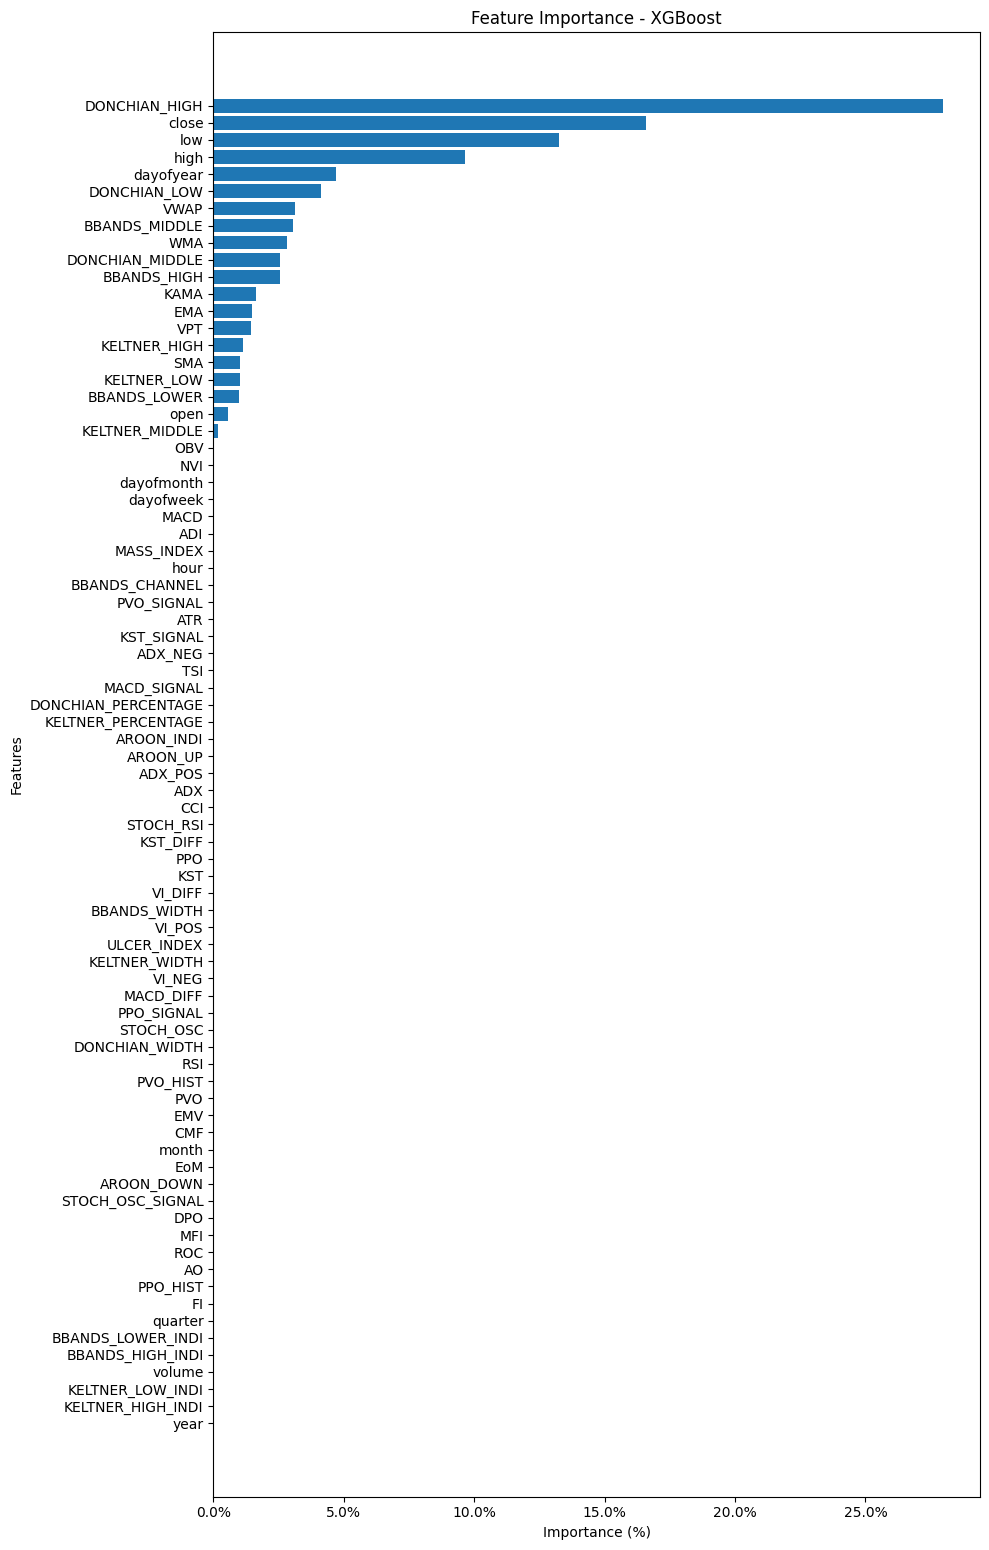

In [120]:
import matplotlib.ticker as ticker

importance_df["gain_pct"] = (importance_df["avg_gain"] / importance_df["avg_gain"].sum()) * 100

plt.figure(figsize=(10, 0.2 * len(importance_df)))

plt.barh(importance_df["feature"], importance_df["gain_pct"])
plt.xlabel("Importance (%)")
plt.ylabel("Features")
plt.title("Feature Importance - XGBoost")

plt.gca().invert_yaxis()

# Show x-axis as percentage with 1 decimal
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))

plt.tight_layout()
plt.show()

In [122]:
importance_df.head(5)

,feature,avg_gain,gain_pct
0,DONCHIAN_HIGH,2.605861e+10,27.989601
1,close,1.544507e+10,16.589576
2,low,1.233007e+10,13.243749
3,high,8.982381e+09,9.647990
4,dayofyear,4.364436e+09,4.687848
